In [2]:
"""Preproceso los datos"""

'Preproceso los datos'

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
db = pd.read_csv("dataset.csv")
db.rename(columns={'Sequence': 'DNABERT_Sequence'}, inplace=True)
db

,Header,DNABERT_Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,>MG559732.1.<1.>690,GATATTGGTACTTTATATTTAATATTCGCAGGGTTTGCTGGTATTA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Clydonella_218657,Clydonella sawyeri_2201168
1,>KF895381.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTATAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
2,>KF895380.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTATAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
3,>KF895382.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTGTAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
4,>MH910097.1.42453.44279,ATGCATCGTCAAGATTTAATTTTAAAAAAATTAAATAAAAAATTTG...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
...,...,...,...,...,...,...,...,...,...
1779511,>OK643902.1.2082.3653,GTGTCTCCTGCTATTCGGTGGCTCTGTTCCACAAGTCATAAAGATA...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Chroodactylon_101918,Chroodactylon ornatum_139907
1779512,>OK643915.1.1.1572,GTGTCTCCTGCTGTTCGGTGGCTATGCTCTACTAGCCACAAAGATA...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Chroothece_362227,Chroothece mobilis_362228
1779513,>OK643891.1.2209.3744,ATGATACTCGGAACATGATCAGCCAGTATCGGAACACTACTGAGCC...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Rhodosorus_101923,Rhodosorus marinus_101924
1779514,>OK643952.1.1.1602,ATGCGCTGGCTCTATTCTACTTCTCACAAGGACATCGCCCTCCTCT...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Stylonema_35154,Stylonema alsidii_35155


In [4]:
animal_phyla = [
    'Chordata_7711',
    'Echinodermata_7586',
    'Hemichordata_10219',
    'Arthropoda_6656',
    'Onychophora_27563',
    'Tardigrada_42241',
    'Nematoda_6231',
    'Nematomorpha_33310',
    'Kinorhyncha_51516',
    'Priapulida_33467',
    'phylum_Micrognathozoa_195505',
    'Chaetognatha_10229',
    'Gnathostomulida_66780',
    'Rotifera_10190',
    'Dicyemida_10215',
    'Orthonectida_33209',
    'Acanthocephala_10232',
    'Annelida_6340',
    'Brachiopoda_7568',
    'Bryozoa_10205',
    'Cycliophora_69815',
    'Entoprocta_43120',
    'Gastrotricha_33313',
    'Mollusca_6447',
    'Nemertea_6217',
    'Phoronida_120557',
    'Platyhelminthes_6157',
    'Xenacoelomorpha_1312402',
    'Cnidaria_6073',
    'Ctenophora_10197',
    'Placozoa_10226',
    'Porifera_6040'
]
print(len(animal_phyla))

32


In [5]:
#Separate the phyla that are animals

dataset_animalia = db[db['Phylum'].isin(animal_phyla)]
dataset_rest = db[~db['Phylum'].isin(animal_phyla)]

In [6]:
taxonomy = "Phylum"
taxonomy_types = dataset_animalia[taxonomy].unique()
print(taxonomy_types)
print(len(taxonomy_types))

['Chordata_7711' 'Echinodermata_7586' 'Hemichordata_10219'
 'Arthropoda_6656' 'Onychophora_27563' 'Tardigrada_42241' 'Nematoda_6231'
 'Nematomorpha_33310' 'Kinorhyncha_51516' 'Priapulida_33467'
 'phylum_Micrognathozoa_195505' 'Chaetognatha_10229'
 'Gnathostomulida_66780' 'Rotifera_10190' 'Dicyemida_10215'
 'Orthonectida_33209' 'Acanthocephala_10232' 'Annelida_6340'
 'Brachiopoda_7568' 'Bryozoa_10205' 'Cycliophora_69815' 'Entoprocta_43120'
 'Gastrotricha_33313' 'Mollusca_6447' 'Nemertea_6217' 'Phoronida_120557'
 'Platyhelminthes_6157' 'Xenacoelomorpha_1312402' 'Cnidaria_6073'
 'Ctenophora_10197' 'Placozoa_10226' 'Porifera_6040']
32


In [7]:
samples_lost = len(db) - len(dataset_animalia)
print(f"Samples lost: {samples_lost} ({samples_lost/len(db)*100:.2f}%)")
print(f"Original samples: {len(dataset_animalia) + len(dataset_rest)}")
print(f"Remaining samples: {len(dataset_animalia)} ({len(dataset_animalia)/len(db)*100:.2f}%)")

Samples lost: 39590 (2.22%)
Original samples: 1779516
Remaining samples: 1739926 (97.78%)


In [8]:
# Check Species column
# Unique species in original dataset
original_species = set(db['Species'].unique())
# Unique species in remaining dataset
remaining_species = set(dataset_animalia['Species'].unique())
# Species lost
lost_species = original_species - remaining_species

print(f"\nSpecies lost: {len(lost_species)} ({len(lost_species)/len(original_species)*100:.2f}%)")
print(f"Original unique species: {len(original_species)}")
print(f"Remaining unique species: {len(remaining_species)} ({len(remaining_species)/len(original_species)*100:.2f}%)")



Species lost: 9433 (4.01%)
Original unique species: 235083
Remaining unique species: 225650 (95.99%)


In [9]:
# Check Genus column
# Unique genera in original dataset
original_genus = set(db['Genus'].unique())
# Unique genera in remaining dataset
remaining_genus = set(dataset_animalia['Genus'].unique())
# Genera lost
lost_genus = original_genus - remaining_genus

print(f"\nGenera lost: {len(lost_genus)} ({len(lost_genus)/len(original_genus)*100:.2f}%)")
print(f"Original unique genera: {len(original_genus)}")
print(f"Remaining unique genera: {len(remaining_genus)} ({len(remaining_genus)/len(original_genus)*100:.2f}%)")



Genera lost: 3245 (5.66%)
Original unique genera: 57326
Remaining unique genera: 54081 (94.34%)


In [10]:
dataset_animalia

,Header,DNABERT_Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
7911,>AP009352.1.1.1548,GTGTACATAACTCGATGGTTATTTTCTACCAACCACAAAGACATCG...,Eukaryota_2759,Chordata_7711,Leptocardii_2682552,Amphioxiformes_2682553,Branchiostomatidae_7736,Asymmetron_355595,Asymmetron inferum_426587
7912,>LC185086.1.<1.>671,TGGCGCTCCTGATATAGCTTTTCCACGTATAAACAATATAAGTTTT...,Eukaryota_2759,Chordata_7711,Leptocardii_2682552,Amphioxiformes_2682553,Branchiostomatidae_7736,Asymmetron_355595,Asymmetron inferum_426587
7913,>LC185085.1.<1.>668,TGGCGCTCCTGATATAGCTTTTCCACGTATAAACAATATAAGTTTT...,Eukaryota_2759,Chordata_7711,Leptocardii_2682552,Amphioxiformes_2682553,Branchiostomatidae_7736,Asymmetron_355595,Asymmetron inferum_426587
7914,>MN807037.1.<1.>642,AATAGTTGGCACAGCAATAAGTCTTCTTATCCGTGCAGAACTATCT...,Eukaryota_2759,Chordata_7711,Leptocardii_2682552,Amphioxiformes_2682553,Branchiostomatidae_7736,Asymmetron_355595,Asymmetron lucayanum_223987
7915,>AB201325.1.<1.>1035,ACAGCCCACGCATTTGTTATGATTTTCTTTATGGTTATGCCCGTAA...,Eukaryota_2759,Chordata_7711,Leptocardii_2682552,Amphioxiformes_2682553,Branchiostomatidae_7736,Asymmetron_355595,Asymmetron lucayanum_223987
...,...,...,...,...,...,...,...,...,...
1747832,>MN175682.1.<1.>492,ATATTACCGGGGTTTGGTATGATATCTCAAATTGTTCCCACATTTG...,Eukaryota_2759,Porifera_6040,Homoscleromorpha_80999,Homosclerophorida_81000,Plakinidae_81001,Plakortis_86044,Plakortis simplex_252963
1747833,>HQ269362.1.11266.12813,ATGAGTAATTTTTTAGTGCGTTGAANTTTTTCTACAAACCATAAAG...,Eukaryota_2759,Porifera_6040,Homoscleromorpha_80999,Homosclerophorida_81000,Plakinidae_81001,Plakortis_86044,Plakortis simplex_252963
1747834,>KX668521.1.<1.>830,TTTTTTTTTAGTTATGCCAGTTATGATTGGGGGGGTTTGGGAAATT...,Eukaryota_2759,Porifera_6040,Homoscleromorpha_80999,Homosclerophorida_81000,Plakinidae_81001,Plakortis_86044,Plakortis symbiotica_1886679
1747835,>KX668531.1.<1.>840,TTTTTTTTTTTAGTTATGCCAGTTATGATTGGGGGGTTTGGGAATT...,Eukaryota_2759,Porifera_6040,Homoscleromorpha_80999,Homosclerophorida_81000,Plakinidae_81001,Plakortis_86044,Plakortis symbiotica_1886679


In [ ]:
dataset_rest

,Header,DNABERT_Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,>MG559732.1.<1.>690,GATATTGGTACTTTATATTTAATATTCGCAGGGTTTGCTGGTATTA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Clydonella_218657,Clydonella sawyeri_2201168
1,>KF895381.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTATAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
2,>KF895380.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTATAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
3,>KF895382.1.<1.>897,ACTTTATATTTATTGTTTGCAGGGTTTGCTGGTGTAATAGGAACAA...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
4,>MH910097.1.42453.44279,ATGCATCGTCAAGATTTAATTTTAAAAAAATTAAATAAAAAATTTG...,Eukaryota_2759,Discosea_555280,Flabellinia_1485085,order_Vannellidae_95227,Vannellidae_95227,Paravannella_1443143,Paravannella minima_1443144
...,...,...,...,...,...,...,...,...,...
1779511,>OK643902.1.2082.3653,GTGTCTCCTGCTATTCGGTGGCTCTGTTCCACAAGTCATAAAGATA...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Chroodactylon_101918,Chroodactylon ornatum_139907
1779512,>OK643915.1.1.1572,GTGTCTCCTGCTGTTCGGTGGCTATGCTCTACTAGCCACAAAGATA...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Chroothece_362227,Chroothece mobilis_362228
1779513,>OK643891.1.2209.3744,ATGATACTCGGAACATGATCAGCCAGTATCGGAACACTACTGAGCC...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Rhodosorus_101923,Rhodosorus marinus_101924
1779514,>OK643952.1.1.1602,ATGCGCTGGCTCTATTCTACTTCTCACAAGGACATCGCCCTCCTCT...,Eukaryota_2759,Rhodophyta_2763,Stylonematophyceae_446134,Stylonematales_282338,Stylonemataceae_446133,Stylonema_35154,Stylonema alsidii_35155


DNA SEQUENCE LENGTH STATISTICS
Mean length:   679.72 bp
Median length: 648.00 bp
Min length:    100 bp
Max length:    2298 bp
Total sequences: 1779516


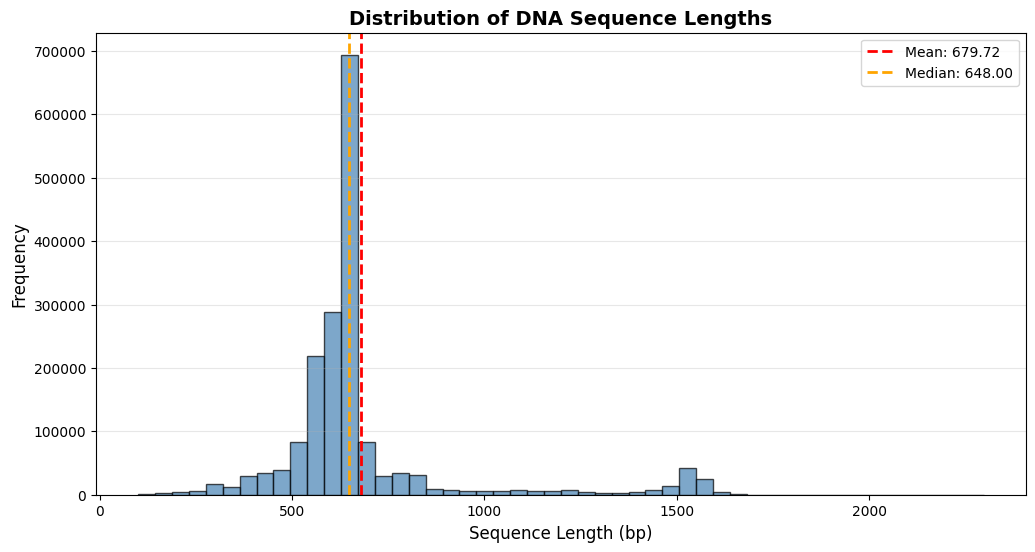

In [12]:
# Calculate sequence lengths
db['seq_length'] = db['DNABERT_Sequence'].str.len()

# Calculate statistics
mean_length = db['seq_length'].mean()
median_length = db['seq_length'].median()
min_length = db['seq_length'].min()
max_length = db['seq_length'].max()

# Print statistics
print("=" * 50)
print("DNA SEQUENCE LENGTH STATISTICS")
print("=" * 50)
print(f"Mean length:   {mean_length:.2f} bp")
print(f"Median length: {median_length:.2f} bp")
print(f"Min length:    {min_length} bp")
print(f"Max length:    {max_length} bp")
print(f"Total sequences: {len(db)}")
print("=" * 50)

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(db['seq_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_length:.2f}')
plt.axvline(median_length, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_length:.2f}')

plt.xlabel('Sequence Length (bp)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of DNA Sequence Lengths', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

"""
# Save the plot
plt.tight_layout()
plt.savefig('sequence_length_distribution.png', dpi=300)
print("\nHistogram saved as 'sequence_length_distribution.png'")
"""

# Show the plot
plt.show()

In [ ]:
"""Sacar secuencias con pocos bp"""

In [13]:
min_length = 450
df_animalia_filtered = dataset_animalia[dataset_animalia['DNABERT_Sequence'].str.len() >= min_length]

In [14]:
samples_lost = len(dataset_animalia) - len(df_animalia_filtered)
print(f"Samples lost: {samples_lost} ({samples_lost/len(db)*100:.2f}%)")
print(f"Original samples: {len(dataset_animalia)}")
print(f"Remaining samples: {len(df_animalia_filtered)} ({len(df_animalia_filtered)/len(dataset_animalia)*100:.2f}%)")

Samples lost: 103624 (5.82%)
Original samples: 1739926
Remaining samples: 1636302 (94.04%)


In [15]:
# Check Species column
# Unique species in original dataset
original_species = set(db['Species'].unique())
# Unique species in remaining dataset
remaining_species = set(df_animalia_filtered['Species'].unique())
# Species lost
lost_species = original_species - remaining_species

print(f"\nSpecies lost: {len(lost_species)} ({len(lost_species)/len(original_species)*100:.2f}%)")
print(f"Original unique species: {len(original_species)}")
print(f"Remaining unique species: {len(remaining_species)} ({len(remaining_species)/len(original_species)*100:.2f}%)")


Species lost: 18948 (8.06%)
Original unique species: 235083
Remaining unique species: 216135 (91.94%)


In [16]:
# Check Genus column
# Unique genera in original dataset
original_genus = set(db['Genus'].unique())
# Unique genera in remaining dataset
remaining_genus = set(dataset_animalia['Genus'].unique())
# Genera lost
lost_genus = original_genus - remaining_genus

print(f"\nGenera lost: {len(lost_genus)} ({len(lost_genus)/len(original_genus)*100:.2f}%)")
print(f"Original unique genera: {len(original_genus)}")
print(f"Remaining unique genera: {len(remaining_genus)} ({len(remaining_genus)/len(original_genus)*100:.2f}%)")


Genera lost: 3245 (5.66%)
Original unique genera: 57326
Remaining unique genera: 54081 (94.34%)


In [17]:
df_animalia_filtered.to_csv('dataset_animalia.csv', index=False)

In [18]:
dataset_animalia.to_csv('dataset_animalia.csv', index=False)